# Проектная работа: "Рынок заведений общественного питания Москвы"
## Описание проекта
<br>Инвесторы из фонда «Shut Up and Take My Money» решили попробовать себя в новой области и открыть заведение общественного питания в Москве. Заказчики ещё не знают, что это будет за место: кафе, ресторан, пиццерия, паб или бар, — и какими будут расположение, меню и цены.</br>
<br>Для начала они просят вас — аналитика — подготовить исследование рынка Москвы, найти интересные особенности и презентовать полученные результаты, которые в будущем помогут в выборе подходящего инвесторам места.</br>
<br>Постарайтесь сделать презентацию информативной и лаконичной. Её структура и оформление сильно влияют на восприятие информации читателями вашего исследования. Выбирать инструменты (matplotlib, seaborn и другие) и типы визуализаций вы можете самостоятельно.</br>
<br>Вам доступен датасет с заведениями общественного питания Москвы, составленный на основе данных сервисов Яндекс Карты и Яндекс Бизнес на лето 2022 года. Информация, размещённая в сервисе Яндекс Бизнес, могла быть добавлена пользователями или найдена в общедоступных источниках. Она носит исключительно справочный характер — количество посадочных мест.</br>

### Описание данных
Файл moscow_places.csv:
<br>- name — название заведения;</br>
<br>- address — адрес заведения;</br>
<br>- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;</br>
<br>- hours — информация о днях и часах работы;</br>
<br>- lat — широта географической точки, в которой находится заведение;</br>
<br>- lng — долгота географической точки, в которой находится заведение;</br>
<br>- rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);</br>
<br>- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;</br>
<br>- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:</br>
<br>«Средний счёт: 1000–1500 ₽»;</br>
<br>«Цена чашки капучино: 130–220 ₽»;</br>
<br>«Цена бокала пива: 400–600 ₽».</br>
<br>и так далее;</br>
<br>- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:</br>
<br>Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.</br>
<br>Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.</br>
<br>Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.</br>
<br>- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:</br>
<br>Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.</br>
<br>Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.</br>
<br>Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.</br>
<br>- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):</br>
<br>0 — заведение не является сетевым</br>
<br>1 — заведение является сетевым</br>
<br>- district — административный район, в котором находится заведение, например Центральный административный округ;</br>
<br>- seats — количество посадочных мест.ение False — в противоположном случае.количество посадочных мест.</br>

### Содержание
* 1) [Загрузка данных и изучение общей информации.](#section_id)
* 2) [Предобработка данных.](#section_id2)
* 3) [Анализ данных.](#section_id3)
* 4) [Детализируемое исследование: открытие кофейни.](#section_id4)

## Шаг 1. Импорт библиотек и предварительный осмотр <a id='section_id'></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from plotly import graph_objects as go
from plotly.subplots import make_subplots
import json
from folium import Map, Marker, Figure
from folium.plugins import MarkerCluster
from folium.features import CustomIcon
import warnings
warnings.filterwarnings('ignore')


In [ ]:
try:
    data_rests= pd.read_csv('../data/moscow_places.csv')
except:
    data_rests= pd.read_csv('../data/moscow_places.csv')

In [ ]:
# проверим открывается ли датафрейм
data_rests.head()

                   name  category                              address  \
0                WoWфли      кафе           Москва, улица Дыбенко, 7/1   
1        Четыре комнаты  ресторан   Москва, улица Дыбенко, 36, корп. 1   
2                 Хазри      кафе       Москва, Клязьминская улица, 15   
3  Dormouse Coffee Shop   кофейня  Москва, улица Маршала Федоренко, 12   
4             Иль Марко  пиццерия      Москва, Правобережная улица, 1Б   

                          district  \
0  Северный административный округ   
1  Северный административный округ   
2  Северный административный округ   
3  Северный административный округ   
4  Северный административный округ   

                                               hours        lat        lng  \
0                             ежедневно, 10:00–22:00  55.878494  37.478860   
1                             ежедневно, 10:00–22:00  55.875801  37.484479   
2  пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...  55.889146  37.525901   
3             

In [ ]:
# проверим общую информацию о датасете
data_rests.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               8406 non-null   object 
 1   category           8406 non-null   object 
 2   address            8406 non-null   object 
 3   district           8406 non-null   object 
 4   hours              7870 non-null   object 
 5   lat                8406 non-null   float64
 6   lng                8406 non-null   float64
 7   rating             8406 non-null   float64
 8   price              3315 non-null   object 
 9   avg_bill           3816 non-null   object 
 10  middle_avg_bill    3149 non-null   float64
 11  middle_coffee_cup  535 non-null    float64
 12  chain              8406 non-null   int64  
 13  seats              4795 non-null   float64
dtypes: float64(6), int64(1), object(7)
memory usage: 919.5+ KB


### Вывод: 
1) Всего в датафрейме 8406 записей;
2) Пропуски присутствуют в 6 столбцах, дубликатов нет;
3) Необходимо обработать столбцы hours и address, для создания новых столбцов;
4) Типы столбцов имеют корректный тип данных.

## Шаг 2. Предобработка данных <a id='section_id2'></a>

In [ ]:
# переведем столбцы со строковыми данными в нижний регистр
for column in ['name', 'category', 'address', 'hours', 'price', 'avg_bill']:
    data_rests[column] = data_rests[column].str.lower()

In [ ]:
#выявим общее количество дубликатов
data_rests.duplicated().sum()

0

In [ ]:
#выявим общее количество пропущенных значений
data_rests.isna().sum()

name                    0
category                0
address                 0
district                0
hours                 536
lat                     0
lng                     0
rating                  0
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
chain                   0
seats                3611
dtype: int64

In [ ]:
#вычислим долю пропущенных значений (NaN) в каждом столбце датафрейма и преобразует полученные значения в проценты.
pd.DataFrame(round(data_rests.isna().mean()*100,)).style.background_gradient('Greens')

Вывод : Как мы видим в столбцах price, avg_bill, middle_avg_bill, middle_coffee_cup и seats огромный процент пропущенных значений, удалить их нельзя, так как это скажется на дальнейшем анализе, заменять значения пока нельзя, т.к на наличие пропусков влияют много факторов (отсутствие "каппучино в меню, отсутствие ценовых категорий и тп.), возможно можно будет их заполнить в течении всего анализа, как прояснится дополнительная информация.

In [ ]:
# проверим уникальные значения округов для выявления граматических ошибок
data_rests['district'].unique()

array(['Северный административный округ',
       'Северо-Восточный административный округ',
       'Северо-Западный административный округ',
       'Западный административный округ',
       'Центральный административный округ',
       'Восточный административный округ',
       'Юго-Восточный административный округ',
       'Южный административный округ',
       'Юго-Западный административный округ'], dtype=object)

In [ ]:
# проверим уникальные значения категорий ресторанов для выявления граматических ошибок
data_rests['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

Вывод: Округи и катгории заведении не имеют ошибок с данными можно работать и проводить анализ.

In [ ]:
# добавим новые столбцы и проверим результат
data_rests['street']=data_rests['address'].str.split(',').str[1].str.strip()
data_rests.head(10)
#PS добавлен метод для удаления пробелов

                   name         category  \
0                wowфли             кафе   
1        четыре комнаты         ресторан   
2                 хазри             кафе   
3  dormouse coffee shop          кофейня   
4             иль марко         пиццерия   
5          sergio pizza         пиццерия   
6           огни города          бар,паб   
7            mr. уголёк  быстрое питание   
8           donna maria         ресторан   
9                готика             кафе   

                                   address                         district  \
0               москва, улица дыбенко, 7/1  Северный административный округ   
1       москва, улица дыбенко, 36, корп. 1  Северный административный округ   
2           москва, клязьминская улица, 15  Северный административный округ   
3      москва, улица маршала федоренко, 12  Северный административный округ   
4          москва, правобережная улица, 1б  Северный административный округ   
5             москва, ижорская улица, вл8

In [ ]:
# создадим столбец для определения круглосуточных заведений
data_rests['is_24_7'] = data_rests.apply(lambda x: True if 'ежедневно, круглосуточно' in str(x['hours']) else False, axis=1)
data_rests.head(25)                              

                    name         category  \
0                 wowфли             кафе   
1         четыре комнаты         ресторан   
2                  хазри             кафе   
3   dormouse coffee shop          кофейня   
4              иль марко         пиццерия   
5           sergio pizza         пиццерия   
6            огни города          бар,паб   
7             mr. уголёк  быстрое питание   
8            donna maria         ресторан   
9                 готика             кафе   
10        great room bar          бар,паб   
11           шашлык шефф             кафе   
12              заправка             кафе   
13               буханка         булочная   
14              у сильвы          бар,паб   
15             дом обеда         столовая   
16         база стритфуд             кафе   
17    чайхана беш-бармак         ресторан   
18               час-пик         столовая   
19               пекарня         булочная   
20        чебуреки манты             кафе   
21        

### Вывод:
<br>1) Были изучены дубликаты в данных, явных дубликатов не обнаружено</br>
<br>2) Были изучены пропуски в столбцах, пропусков много, но на данном этапе их лучше не трогать, возможно в ходе исследования станет понятнее и тогда можно будет повторно вернуться к этой задаче.</br>
<br>3) Была выполнена предобработка и созданы новые столбцы "street" с названиями улиц из столбца с адресом и is_24_7 с обозначением, что заведение работает ежедневно и круглосуточно (24/7).</br>

## Шаг 3. Анализ данных <a id='section_id3'></a>

### Построим график визуализации количество объектов общественного питания по категориям

In [ ]:
#сгруппируем данные по категориям и долю категорий ресторанов от общего количества

category_rests = data_rests.groupby('category', as_index=False).agg(count_object=('name', 'count'))
category_rests['ratio'] = category_rests['count_object'] / category_rests['count_object'].sum()
category_rests.head(10).sort_values(by='count_object', ascending=False)

          category  count_object     ratio
3             кафе          2378  0.282893
6         ресторан          2043  0.243041
4          кофейня          1413  0.168094
0          бар,паб           765  0.091006
5         пиццерия           633  0.075303
2  быстрое питание           603  0.071734
7         столовая           315  0.037473
1         булочная           256  0.030454

In [ ]:
colorscale = px.colors.sequential.Viridis
colors = [colorscale[i] for i in range(len(category_rests))]
normed_values = (category_rests['count_object'] - category_rests['count_object'].min()) / (
    category_rests['count_object'].max() - category_rests['count_object'].min()
)
colors = [colorscale[int(value * (len(colorscale) - 1))] for value in normed_values]
# Создание графика
fig = go.Figure(data=[go.Pie(
    labels=category_rests['category'], 
    values=category_rests['count_object'], 
    marker=dict(colors=colors))
])

fig.update_layout(title='Доли категорий заведений общественного питания')

# Отображаем график
fig.show()

In [ ]:
colorscale = px.colors.sequential.Viridis
colors = [colorscale[i] for i in range(len(category_rests))]
normed_values = (category_rests['count_object'] - category_rests['count_object'].min()) / (
    category_rests['count_object'].max() - category_rests['count_object'].min()
)
colors = [colorscale[int(value * (len(colorscale) - 1))] for value in normed_values]
fig_category_rests = go.Figure(go.Bar(
    x=category_rests['category'],
    y=category_rests.sort_values('ratio', ascending=False)['ratio'],
    marker=dict(color=colors)))
fig_category_rests.update_layout(
    title='Процент заведений по категориям',
    yaxis_title='Процент',
    xaxis_title='Категория',
    height=500,
)

fig_category_rests.show()

<br>1) Список заведений по категориям (по убыванию количества):
28% - кафе
24% - ресторан
17% - кофейня
7%-9% - бар/паб, пиццерия, быстрое питание
3%-4% - столовая, булочная</br>
<br>2) Как мы видим самая популярные категории заведения- "кафе" и "ресторан" 28% и 24%;</br>
<br>3) Самая непопулярная булочные и столовые.</br>

### Построим график отношения количества посадочных мест к категориям

In [ ]:
# проверим сводную статистику по посадочным местам
display(data_rests['seats'].describe())

count    4795.000000
mean      108.421689
std       122.833396
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

In [ ]:
# установим заглушку, присутствуют выбросы и сгруппируем данные
data_rests_seats_sorted = data_rests.query('seats > 0 and seats < 140')
data_rests_seats_sorted = data_rests.groupby('category').count().reset_index()

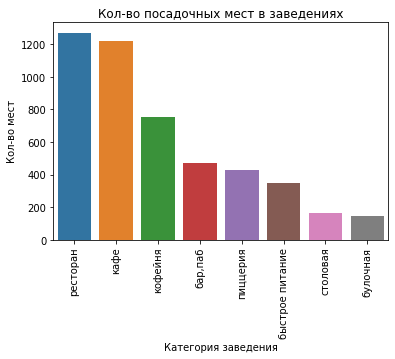

In [ ]:
fig_data_rests_seats_sorted = sns.barplot(x='category', y='seats', data=data_rests_seats_sorted.sort_values(by='seats', ascending=False));
fig_data_rests_seats_sorted.set_title('Кол-во посадочных мест в заведениях');
fig_data_rests_seats_sorted.set_xlabel('Категория заведения');
fig_data_rests_seats_sorted.set_ylabel('Кол-во мест');
plt.xticks(rotation=90);
plt.show();

Вывод:
В график попадают критические значения, которые исказают анализ, попробуем провести анализ по медианному числу посадочных мест.

In [ ]:
seats_mean=data_rests.groupby('category').agg({'seats': 'median'}).sort_values(by='seats', ascending=False).reset_index()
seats_mean['seats'] = round(seats_mean['seats'])  
seats_mean

          category  seats
0         ресторан   86.0
1          бар,паб   82.0
2          кофейня   80.0
3         столовая   76.0
4  быстрое питание   65.0
5             кафе   60.0
6         пиццерия   55.0
7         булочная   50.0

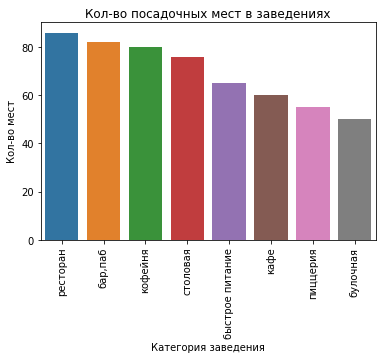

In [ ]:
fig_data_rests_seats_sorted = sns.barplot(x='category', y='seats', data=seats_mean.sort_values(by='seats', ascending=False));
fig_data_rests_seats_sorted.set_title('Кол-во посадочных мест в заведениях');
fig_data_rests_seats_sorted.set_xlabel('Категория заведения');
fig_data_rests_seats_sorted.set_ylabel('Кол-во мест');
plt.xticks(rotation=90);
plt.show();

<br>1) Исходя из графика, больше всего посадочных мест в заведениях типа кафе и ресторан.</br>
<br>2) По среднему количеству посадочных мест больше всего у баров и пабов.</br>
<br>3) Меньше всего в категориях: столовая и булочная.</br>
<br>4) Это не удивительно, так как рестораны пользуются большим спросом и посадочных мест там соответственно больше.</br>

## Построим график соотношения сетевых и несетевых заведений

In [ ]:
#для начала проверим количество
data_rests.groupby('chain')['category'].count().sort_values()


chain
1    3205
0    5201
Name: category, dtype: int64

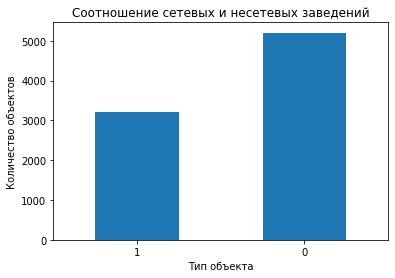

In [ ]:
fig_data_rests_chain = data_rests.groupby('chain')['category'].count().sort_values().plot(kind='bar')
fig_data_rests_chain.set_title('Соотношение сетевых и несетевых заведений')
fig_data_rests_chain.set_xlabel('Тип объекта')
fig_data_rests_chain.set_ylabel('Количество объектов')
plt.xticks(rotation=0)
plt.show()

1) Как видим на графике, сетевые заведения на 2000 заведений меньше, хотя порой кажется, что монополисты все поработили, исходя из этого анализа это далеко не так.

### Категории сетевых заведений

In [ ]:
# установим заглушку для типов заведеий, которые не являются несетевыми
network_rests = (data_rests.query('chain != 0').groupby(by = ['category', 'chain'], as_index=False)
                 .agg(count_object=('name', 'count'))
                 .sort_values(by='count_object', ascending=False).reset_index(drop=False))
network_rests.head(10)

   index         category  chain  count_object
0      3             кафе      1           779
1      6         ресторан      1           730
2      4          кофейня      1           720
3      5         пиццерия      1           330
4      2  быстрое питание      1           232
5      0          бар,паб      1           169
6      1         булочная      1           157
7      7         столовая      1            88

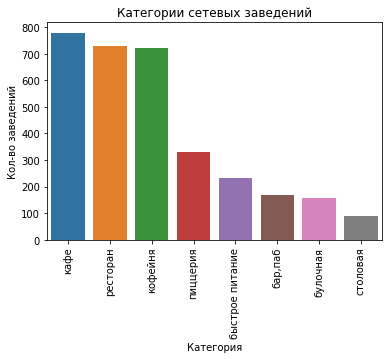

In [ ]:
fig_network_rests = sns.barplot(x='category', y='count_object', data=network_rests.sort_values(by='count_object', ascending=False));
fig_network_rests.set_title('Категории сетевых заведений');
fig_network_rests.set_xlabel('Категория');
fig_network_rests.set_ylabel('Кол-во заведений');
plt.xticks(rotation=90);
plt.show();

In [ ]:
network_rests['ratio'] = network_rests['count_object'] / network_rests['count_object'].sum()
network_rests.head(10).sort_values(by='count_object', ascending=False)

   index         category  chain  count_object     ratio
0      3             кафе      1           779  0.243058
1      6         ресторан      1           730  0.227769
2      4          кофейня      1           720  0.224649
3      5         пиццерия      1           330  0.102964
4      2  быстрое питание      1           232  0.072387
5      0          бар,паб      1           169  0.052730
6      1         булочная      1           157  0.048986
7      7         столовая      1            88  0.027457

In [ ]:
fig_network_rests = go.Figure(go.Bar(
    x=network_rests['category'],
    y=network_rests.sort_values('ratio', ascending=False)['ratio']))
fig_network_rests.update_layout(
    title='Процент сетевых заведений по категориям',
    yaxis_title='Процент',
    xaxis_title='Категория сетевых заведений',
    height=500,
    legend_title_text='Категории'
)

fig_network_rests.show()

In [ ]:
# Группировка данных по статусу и категории, подсчёт количества заведений в каждой группе
network_data = data_rests.groupby(['category', 'chain']).size().reset_index(name='count')

# Сортировка по количеству заведений и выбор топ-15
network = network_data.sort_values(by='count', ascending=False).head(15)

In [ ]:
# Построим график для определения соотношений сетевых и несетевых заведений
fig_network = px.bar(network,
x='category', y='count', color='chain', barmode='stack', width=800, height=600)
fig_network.update_layout(title = 'Соотношение сетевых и несетевых заведений', 
                                  xaxis_title= 'Категория', 
                                  yaxis_title='Кол-во заведений',
                                  legend_title= 'Статус')
fig_network.layout.height = 600
fig_network.show();

<br>1) Самые количественные категории сетевых заведений являются "кафе", "ресторан" и "кофейня", они же занимают от 22 до 24% от общего числа.</br>
<br>2) А вот столовые не пользуются популярностью для открытия > 100, так же их количество самое маленькое от общего числа 2,7%.</br>
<br>3) Огромный разрыв между 3 и 4 местом, почти 400 заведений.</br>
<br>4) Все столовые ясляются несетевыми заведениями</br>
<br>5) Категории "пиццерия" и "булочная" единственные из 8 категорий, где количество сетевых заведений выше, чем несетевых</br>

### Заведения, которые чаще являются сетевыми

In [ ]:
# сгруппируем данные по категориям и типу заведения
data_rests_chain_network =  data_rests.groupby(by=['category', 'chain'], as_index=False).agg(count=('name', 'count'))

In [ ]:
# выведем топ-15 заведений на экран
data_rests_top_15= data_rests.groupby('name', as_index=False).agg(count_object=('category', 'count')).sort_values('count_object', ascending=False)
display(data_rests_top_15.head(15))

                                     name  count_object
2825                                 кафе           189
5418                          шоколадница           120
2532                       домино'с пицца            77
2500                           додо пицца            74
1137                     one price coffee            72
5491                         яндекс лавка            69
413                                 cofix            65
1263                                prime            50
4993                           хинкальная            44
5319                               шаурма            43
3178                             кофепорт            42
3236  кулинарная лавка братьев караваевых            39
4700                              теремок            38
5112                              чайхана            37
4172                             ресторан            34

In [ ]:
# необходимо отсортировать срез, так как присутствуют общие названия заведений
new_data_rests_top_15=data_rests_top_15.query('name != "кафе" and name != "хинкальная" and name != "шаурма" and name != "чайхана" and name != "ресторан" and name != "столовая"').head(15)
display(new_data_rests_top_15.head(15))

                                     name  count_object
5418                          шоколадница           120
2532                       домино'с пицца            77
2500                           додо пицца            74
1137                     one price coffee            72
5491                         яндекс лавка            69
413                                 cofix            65
1263                                prime            50
3178                             кофепорт            42
3236  кулинарная лавка братьев караваевых            39
4700                              теремок            38
2088                              буханка            32
344                              cofefest            32
3632                                му-му            27
508                            drive café            24
3175                            кофемания            23

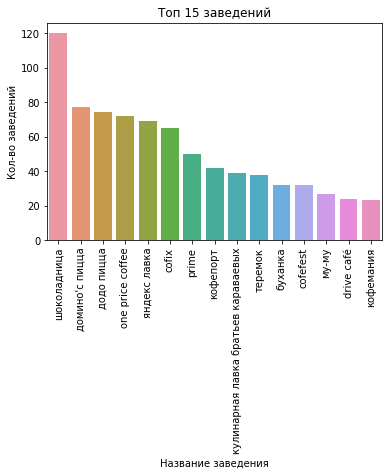

In [ ]:
#посмтроим график топ-15 заведений по количеству
fig_new_data_rests_top_15 = sns.barplot(x='name', y='count_object', data=new_data_rests_top_15.sort_values(by='count_object', ascending=False));
fig_new_data_rests_top_15.set_title('Топ 15 заведений');
fig_new_data_rests_top_15.set_xlabel('Название заведения');
fig_new_data_rests_top_15.set_ylabel('Кол-во заведений');
plt.xticks(rotation=90);
plt.show();

In [ ]:
#проверим сколько заведений из графика являются сетевыми
name_network_rests = (data_rests.query('chain != 0 and name != "кафе" and name != "хинкальная" and name != "шаурма" and name != "чайхана" and name != "ресторан" and name != "столовая"').groupby(by = ['name', 'chain', 'category'], as_index=False)
                 .agg(count_object=('name', 'count'))
                 .sort_values(by='count_object', ascending=False).reset_index(drop=False)).head(15)
name_network_rests

    index                                 name  chain  category  count_object
0    1118                          шоколадница      1   кофейня           119
1     496                       домино'с пицца      1  пиццерия            76
2     489                           додо пицца      1  пиццерия            74
3     205                     one price coffee      1   кофейня            71
4    1134                         яндекс лавка      1  ресторан            69
5      72                                cofix      1   кофейня            65
6     241                                prime      1  ресторан            49
7     617                             кофепорт      1   кофейня            42
8     632  кулинарная лавка братьев караваевых      1      кафе            39
9     963                              теремок      1  ресторан            36
10     50                             cofefest      1   кофейня            31
11    384                              буханка      1  булочная 

In [ ]:
# Группировка данных по названию сети и категории, подсчёт количества заведений в каждой группе
grouped_data = data_rests.query('chain != 0 and name != "кафе" and name != "хинкальная" and name != "шаурма" and name != "чайхана" and name != "ресторан" and name != "столовая"').groupby(['name', 'category']).size().reset_index(name='count')

# Сортировка по количеству заведений и выбор топ-15
top_chains = grouped_data.sort_values(by='count', ascending=False).head(15)


In [ ]:
fig_top_chains = px.bar(top_chains,
x='name', y='count', color='category', barmode='stack', width=800, height=600)
fig_top_chains.update_layout(title = 'Топ 15 сетевых заведений', 
                                  xaxis_title= 'Название заведения', 
                                  yaxis_title='Кол-во заведений в сети',
                                  legend_title= 'Категория')
fig_top_chains.layout.height = 600
fig_top_chains.show();

<br>1) Самая популярная сеть заведений - "Шоколадница".</br>
<br>2) Чтоб попасть в топ 15 по Москве, необходимо открыть больше 23 заведения.</br>
<br>3) Среди топ 15 сетевых заведений 5 отсноятся к категории "кофейня", 4 к категории "ресторан", 2 пиццерии, 3 кафе и 1 быстрое питание.</br>

### Количество заведений каждой категории по районам

In [ ]:
# сгруппируем данные по округам и категориям от общего числа
district_data_rests = data_rests.groupby(['district', 'category'], as_index=False).agg(count_object=('name', 'count')).sort_values('count_object', ascending=False)
district_data_rests

                                  district  category  count_object
46      Центральный административный округ  ресторан           670
43      Центральный административный округ      кафе           464
44      Центральный административный округ   кофейня           428
40      Центральный административный округ   бар,паб           364
51    Юго-Восточный административный округ      кафе           282
..                                     ...       ...           ...
32  Северо-Западный административный округ   бар,паб            23
39  Северо-Западный административный округ  столовая            18
63     Юго-Западный административный округ  столовая            17
49    Юго-Восточный административный округ  булочная            13
33  Северо-Западный административный округ  булочная            12

[72 rows x 3 columns]

In [ ]:
# создадим столбчатую диаграмму для количества заведений в административных районах Москвык
fig_district_data_rests = px.bar(district_data_rests,
x='district', y='count_object', color='category', barmode='group', width=800, height=600)
fig_district_data_rests.update_layout(title = 'Количество заведений в административных районах Москвы', 
                                  xaxis_title= 'Округ', 
                                  yaxis_title='Количество Заведений',
                                  legend_title= 'Категория')
fig_district_data_rests.layout.height = 600
fig_district_data_rests.show();

<br>1) Не удивительно, что в ЦАО количество заведений значительно превосходят остальные по численности, так как очень большая проходимость (красивые места, туристы, большое количество рабочих мест).</br>
<br>2) СЗАО на последнем месте из-за большого количества пром зон и большого числа спальных районов, к тому же СЗАО является самым маленьким административным округом москвы.</br>
<br>3) Остальные округа показывают относительно одинаковые показатели.</br>

### Визуализация распределения средних рейтингов по категориям заведений

In [ ]:
# сгруппируем данные по округам и категориям от среднего рейтига
rating_data_rests = data_rests.groupby(['district', 'category'], as_index=False).agg(rating_object=('rating', 'mean')).sort_values('rating_object', ascending=False)

In [ ]:
# создадим столбчатую диаграмму для среднего рейтинга заведений в административных районах Москвы
fig_rating_data_rests = px.bar(rating_data_rests,
x='district', y='rating_object', color='category', barmode='group', orientation='v', width=800)
fig_rating_data_rests.update_layout(title = 'Средний рейтинг заведений в административных районах Москвы', 
                                  xaxis_title= 'Округ', 
                                  yaxis_title='Средний рейтинг',
                                  legend_title= 'Категория', yaxis_range=[3.5, 4.6])
fig_rating_data_rests.layout.height = 600
fig_rating_data_rests.show();

Вывод:
<br>1) Как мы видим, в большинстве округов самая популярная категория по рейтингу является бар, паб. А самые низкие рейтинги в основном у заведений быстрого питания, при этом оценка значительно выше, чем в других округах (4.2)</br>
<br>2) Только в центральном округе категории заведений имеют оценку выше 4.4, большую роль в этом может играть красивая архитектура и спокойная обстановка в центре города.</br>
<br>3) По графику заметно , что низкие, в сравнении с остальными округами, оценки принадлежат ЮВАО.</br>

### Фоновая картограмма

In [ ]:
# для каждого округа посчитаем средний рейтинг заведений в Москве
rating_data = data_rests.groupby('district', as_index=False)['rating'].agg('mean')
display(rating_data)

                                  district    rating
0         Восточный административный округ  4.174185
1          Западный административный округ  4.181551
2          Северный административный округ  4.239778
3  Северо-Восточный административный округ  4.148260
4   Северо-Западный административный округ  4.208802
5       Центральный административный округ  4.377520
6     Юго-Восточный административный округ  4.101120
7      Юго-Западный административный округ  4.172920
8             Южный административный округ  4.184417

In [ ]:
# импортируем карту и хороплет, загружаем JSON-файл с границами округов Москвы
from folium import Map, Choropleth
try:
    state_geo =('https://code.s3.yandex.net/data-analyst/admin_level_geomap.geojson')
except:
    state_geo =('../data/admin_level_geomap.geojson')
# moscow_lat - широта центра Москвы, moscow_lng - долгота центра Москвы
moscow_lat, moscow_lng = 55.751244, 37.618423
state_geo


'https://code.s3.yandex.net/data-analyst/admin_level_geomap.geojson'

In [ ]:
import folium
# создаём карту Москвы
moscow_map = Map(location=[moscow_lat, moscow_lng], zoom_start=10, tiles='Cartodb Positron')
# создаём хороплет с помощью конструктора Choropleth и добавляем его на карту
mm = Choropleth(
    geo_data=state_geo,
    data=rating_data,
    columns=['district', 'rating'],
    key_on='feature.name',
    fill_color='YlOrBr',
    fill_opacity=0.5,
    legend_name='Срелний рейтинг заведений по округам',
).add_to(moscow_map)

mm.geojson.add_child(folium.features.GeoJsonTooltip(['name',], labels=False))

# выводим карту
moscow_map

In [ ]:
marker_cluster = MarkerCluster().add_to(moscow_map)

# пишем функцию, которая принимает строку датафрейма,
# создаёт маркер в текущей точке и добавляет его в кластер marker_cluster
def create_clusters(row):
    Marker(
        [row['lat'], row['lng']],
        popup=f"{row['name']} {row['rating']}",
    ).add_to(marker_cluster)

# применяем функцию create_clusters() к каждой строке датафрейма
data_rests.apply(create_clusters, axis=1)

# выводим карту
moscow_map

<br>1) Исходя из фоновой картограммы самый высокий средний рейтинг у заведений принадлежит заведениям из ЦАО.</br>
<br>2) СВАО, САО, ЗАО, ЮВАО, ЮАО, СЗАО имеют относительно одинаковые рейтинги.</br>
<br>3) А вот самые низкий средний рейтинг у ЮЗАО.</br>

### Топ-15 улиц по количеству заведений

In [ ]:
# сгруппируем данные улиц по количеству ресторанов и выведем топ-15 и преобразуем индекс в список
streets = data_rests.groupby('street').agg(count_object=('name', 'count')).sort_values(
    'count_object', ascending=False).head(15).index.tolist()
# Теперь сгруппируем  улицу и категорию, по количеству, используя отфильтрованный датафрейм, 
# где значение в столбце street находится в top_streets_data_rest
street_cat = data_rests[data_rests['street'].isin(streets)].groupby(['street', 'category'], as_index=False).agg(
    count_object=('name', 'count')).sort_values('count_object', ascending=False)
street_cat


                  street  category  count_object
78         проспект мира      кафе            53
63                  мкад      кафе            45
81         проспект мира  ресторан            45
79         проспект мира   кофейня            36
86     профсоюзная улица      кафе            35
..                   ...       ...           ...
58      люблинская улица  пиццерия             1
68  проспект вернадского  булочная             1
66                  мкад  столовая             1
23  кутузовский проспект  булочная             1
61                  мкад   бар,паб             1

[111 rows x 3 columns]

In [ ]:
fig_street_cat = px.bar(street_cat,
    x='street', y='count_object', color='category', orientation='v', barmode='group')
fig_street_cat.update_layout(title = 'Топ-15 улиц по количеству заведений', 
                                  xaxis_title= 'Название улицы', 
                                  yaxis_title='Количество заведений',
                                  legend_title= 'Категория')
fig_street_cat.show()

Вывод:
<br>1) Проспект мира является самым ресторанным местом Москвы, улица очень длинная от станции метро Сухаревская до северяненского моста, почти 9 километров, охватывает такие места, как спорткомплекс Олимпийский, ВДНХ, останкинский парк, ТЦ Европолис, Рижский вокзал, мечеть, очень много посольств.</br>
<br>2) Архитектура вдоль улицы Проспект Мира в основном Сталинские дома где обычно на 1 этажах открываются кафе и рестораны.</br>

### Подсчет улиц с 1 заведением

In [ ]:
# сгруппируем данные улиц по количеству ресторанов и выведем топ-15 и преобразуем индекс в список
solo_rest = data_rests.groupby('street').agg(count_object=('name', 'count')).sort_values(
    'count_object', ascending=False).query('count_object == 1').index.tolist()
# Теперь сгруппируем категорию и улицу, по количеству, использую срез, где значение в столбце street находится в top_streets_data_rest
solo_rest_street = data_rests[data_rests['street'].isin(solo_rest)].groupby(
    'category', as_index=False).agg(count_object=('name', 'count')).sort_values('count_object', ascending=False).reset_index(drop=False)
# выведем сгруппированный срез
solo_rest_street

   index         category  count_object
0      3             кафе           159
1      6         ресторан            93
2      4          кофейня            84
3      0          бар,паб            39
4      7         столовая            36
5      2  быстрое питание            23
6      5         пиццерия            15
7      1         булочная             8

In [ ]:
solo_rest_street=data_rests.groupby(['street', 'district'], as_index = False)['name'].count().query('name==1')
solo_rest_street

                                   street  \
0                1-й автозаводский проезд   
1                 1-й балтийский переулок   
2                   1-й варшавский проезд   
3                 1-й вешняковский проезд   
5               1-й голутвинский переулок   
...                                   ...   
1471               электрический переулок   
1478  юго-западный административный округ   
1483                  якиманский переулок   
1484           яковоапостольский переулок   
1492                                  № 7   

                                  district  name  
0             Южный административный округ     1  
1          Северный административный округ     1  
2             Южный административный округ     1  
3     Юго-Восточный административный округ     1  
5       Центральный административный округ     1  
...                                    ...   ...  
1471    Центральный административный округ     1  
1478   Юго-Западный административный округ     1  


Вывод
<br>1) Можно сделать вывод, что на улицах с 1 заведением чаще всего открывают кафе, рестораны и кофейни;</br>
<br>2) Всего 1492 заведения, которые на своей улице являются единственными.</br>
<br>3) Это скорее всего связано с тем, что бар, паб, столовая, быстрое питание, пиццерия и булочная открывают обычно там, где большая проходимость клиентов.</br>
<br>4) А кафе, ресторан и кофейня не зависят от проходимости, но доход их зависит от наличия клиентов на той же улице.</br>

### Медианное значение чека для каждого района

In [ ]:
data_rests_avg_bill = data_rests.groupby('district', as_index=False)['middle_avg_bill'].agg('median')
data_rests_avg_bill

                                  district  middle_avg_bill
0         Восточный административный округ            575.0
1          Западный административный округ           1000.0
2          Северный административный округ            650.0
3  Северо-Восточный административный округ            500.0
4   Северо-Западный административный округ            700.0
5       Центральный административный округ           1000.0
6     Юго-Восточный административный округ            450.0
7      Юго-Западный административный округ            600.0
8             Южный административный округ            500.0

In [ ]:
# создаём карту Москвы
moscow_map = Map(location=[moscow_lat, moscow_lng], zoom_start=10, tiles='Cartodb Positron')
# создаём хороплет с помощью конструктора Choropleth и добавляем его на карту
Choropleth(
    geo_data=state_geo,
    data=data_rests_avg_bill,
    columns=['district', 'middle_avg_bill'],
    key_on='feature.name',
    fill_color='PuRd',
    fill_opacity=0.5,
    legend_name='Срелний чек заведения по районам',
).add_to(moscow_map)

# выводим карту
moscow_map

### Вывод:
Самые популярные категории заведения- "кафе" и "ресторан" 28% и 24%, самые непопулярные- "булочная" и "столовая".​

Среднее количество посадочных мест в заведениях - 108, а медианное 75, больше всего посадочных мест в заведениях типа кафе и ресторан​

Несетевых заведений в Москве больше, чем сетевых, соотношение 62% на 38%.​

Самые количественные категории сетевых заведений являются "кафе", "ресторан" и "кофейня", каждая категория насчитывает больше 700 заведений в городе.​

Кафе "Шоколадница" является самой крупной сетью в Москве.​

Самый высокий рейтинг по всем районам у баров, самый низкий рейтинг почти по всем районам у быстрого питания.​

Больше всего заведений в ЦАО, так же это самый рейтинговый район, а самая популярная категория в ЦАО- рестораны, самые низкие рейтинги в ЮВАО, а рейтинги в этом округе принадлежат категории "быстрое питание".​

Самый высокий средний чек в ЦАО и ЗАО, самый низкий в СВАО и ЮВАО.

## Шаг 4. Детализируем исследование: открытие кофейни <a id='section_id4'></a>

### Сколько всего кофеен в датасете? В каких районах их больше всего, каковы особенности их расположения?

In [ ]:
data_rests['category'].unique()

array(['кафе', 'ресторан', 'кофейня', 'пиццерия', 'бар,паб',
       'быстрое питание', 'булочная', 'столовая'], dtype=object)

In [ ]:
# Для начала создадим новый датасет в который войдут кофейни
data_cafe=data_rests.query('category== "кофейня"')
data_cafe.count()
data_cafe.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1413 entries, 3 to 8400
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1413 non-null   object 
 1   category           1413 non-null   object 
 2   address            1413 non-null   object 
 3   district           1413 non-null   object 
 4   hours              1398 non-null   object 
 5   lat                1413 non-null   float64
 6   lng                1413 non-null   float64
 7   rating             1413 non-null   float64
 8   price              476 non-null    object 
 9   avg_bill           721 non-null    object 
 10  middle_avg_bill    200 non-null    float64
 11  middle_coffee_cup  521 non-null    float64
 12  chain              1413 non-null   int64  
 13  seats              751 non-null    float64
 14  street             1413 non-null   object 
 15  is_24_7            1413 non-null   bool   
dtypes: bool(1), float64(6), 

In [ ]:
data_district_cafe=data_cafe.groupby('district', as_index=False)['name'].agg('count').sort_values(by='name',ascending=False)
data_district_cafe

                                  district  name
5       Центральный административный округ   428
2          Северный административный округ   193
3  Северо-Восточный административный округ   159
1          Западный административный округ   150
8             Южный административный округ   131
0         Восточный административный округ   105
7      Юго-Западный административный округ    96
6     Юго-Восточный административный округ    89
4   Северо-Западный административный округ    62

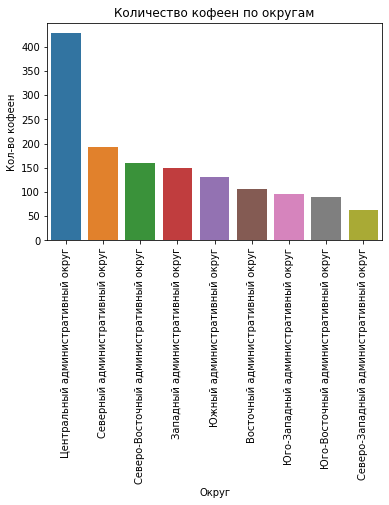

In [ ]:
fig_data_district_cafe = sns.barplot(x='district', y='name', data=data_district_cafe);
fig_data_district_cafe.set_title('Количество кофеен по округам');
fig_data_district_cafe.set_xlabel('Округ');
fig_data_district_cafe.set_ylabel('Кол-во кофеен');
plt.xticks(rotation=90);
plt.show();

In [ ]:
# создаём карту Москвы
cafe_map = Map(location=[moscow_lat, moscow_lng], zoom_start=10, tiles='Cartodb Positron')
# создаём хороплет с помощью конструктора Choropleth и добавляем его на карту
Choropleth(
    geo_data=state_geo,
    data=data_district_cafe,
    columns=['district', 'name'],
    key_on='feature.name',
    fill_color='OrRd',
    fill_opacity=0.5,
    legend_name='Количество кофеен по округам',
).add_to(cafe_map)

# выводим карту
cafe_map

Вывод:
<br>1) Всего в датасете 1413 кофеен.</br>
<br>2) Больше всего кофеен в ЦАО, в 2 раза больше, чем в САО (который на 2ом месте).</br>
<br>3) В других округах гораздо меньше кофеен, чем в ЦАО.</br>

### Есть ли круглосуточные кофейни?

In [ ]:
data_cafe_24 = data_cafe.query('category="кофейня"' and 'is_24_7==True')['name'].reset_index()
data_cafe_24.count()

index    59
name     59
dtype: int64

In [ ]:
cafe_24_7 = data_cafe[data_cafe['is_24_7'] == True]
cafe_24_7.count()

name                 59
category             59
address              59
district             59
hours                59
lat                  59
lng                  59
rating               59
price                25
avg_bill             28
middle_avg_bill      13
middle_coffee_cup    15
chain                59
seats                37
street               59
is_24_7              59
dtype: int64

In [ ]:
grouped_cafe = cafe_24_7.groupby('district', as_index=False)['name'].agg('count')
grouped_cafe 

                                  district  name
0         Восточный административный округ     5
1          Западный административный округ     9
2          Северный административный округ     5
3  Северо-Восточный административный округ     3
4   Северо-Западный административный округ     2
5       Центральный административный округ    26
6     Юго-Восточный административный округ     1
7      Юго-Западный административный округ     7
8             Южный административный округ     1

In [ ]:
# создаём карту Москвы
map_24 = Map(location=[moscow_lat, moscow_lng], zoom_start=10, tiles='Cartodb Positron')
mm = Choropleth(
    geo_data=state_geo,
    data=grouped_cafe,
    columns=['district', 'name'],
    key_on='feature.name',
    fill_color='YlGn',
    fill_opacity=0.5,
    legend_name='Количество кофеен 24/7',
).add_to(map_24)
mm.geojson.add_child(folium.features.GeoJsonTooltip(['name',], labels=False))
map_24

Вывод:
<br>1) Всего 59 кофеен работающий круглосуточно.</br>
<br>2) Больше всего круглосуточный кофеен в ЦАО 26, в то время, как у остальных округов этот показатель не превышает 10.</br>

### Какие у кофеен рейтинги? Как они распределяются по районам?

In [ ]:
data_cafe_rating = data_cafe.groupby('district', as_index=False)['rating'].agg('mean')
data_cafe_rating

                                  district    rating
0         Восточный административный округ  4.282857
1          Западный административный округ  4.195333
2          Северный административный округ  4.291710
3  Северо-Восточный административный округ  4.216981
4   Северо-Западный административный округ  4.325806
5       Центральный административный округ  4.336449
6     Юго-Восточный административный округ  4.225843
7      Юго-Западный административный округ  4.283333
8             Южный административный округ  4.232824

In [ ]:
# необходимо разбить рейтинг по категориям
# создаим функцию для заполнения нового столбца с типом рейтинга
def cafe_rating(row):
    if row['rating'] > 4.5:
        return 'отличный'
    elif row['rating'] <= 4.5 and row['rating'] >= 4:
        return 'хороший'
    elif row['rating'] < 4:
        return 'удовлетворительный'
data_cafe['cafe_rating'] = data_cafe.apply(cafe_rating,axis=1)
data_cafe

                       name category  \
3      dormouse coffee shop  кофейня   
25          в парке вкуснее  кофейня   
45             9 bar coffee  кофейня   
46                 cofefest  кофейня   
52                    cofix  кофейня   
...                     ...      ...   
8356             назис пури  кофейня   
8365           квадрат кофе  кофейня   
8376  шоколад имбирь корица  кофейня   
8385                  cafio  кофейня   
8400          практика кофе  кофейня   

                                         address  \
3            москва, улица маршала федоренко, 12   
25                     москва, парк левобережный   
45         москва, коровинское шоссе, 41, стр. 1   
46          москва, улица маршала федоренко, 6с1   
52                    москва, улица дыбенко, 7/1   
...                                          ...   
8356                москва, люблинская улица, 61   
8365  москва, волгоградский проспект, 73, стр. 1   
8376           москва, грайвороновская улица, 23   

In [ ]:
# сгруппируем данные по округу и категории по количеству
data_cafe_rating = data_cafe.groupby(['district','cafe_rating'])['name'].count().sort_values(ascending= False).reset_index()
data_cafe_rating

                                   district         cafe_rating  name
0        Центральный административный округ             хороший   350
1           Северный административный округ             хороший   128
2   Северо-Восточный административный округ             хороший   116
3           Западный административный округ             хороший   106
4              Южный административный округ             хороший   100
5          Восточный административный округ             хороший    69
6       Юго-Западный административный округ             хороший    69
7        Центральный административный округ            отличный    68
8      Юго-Восточный административный округ             хороший    53
9    Северо-Западный административный округ             хороший    43
10          Северный административный округ            отличный    43
11          Западный административный округ  удовлетворительный    27
12     Юго-Восточный административный округ            отличный    22
13         Восточный

In [ ]:
fig_data_cafe_rating = px.bar(data_cafe_rating,
    x='district', y='name', color='cafe_rating', orientation='v', barmode='group')
fig_data_cafe_rating.update_layout(title = 'Категории рейтинга кофеен по округам', 
                                  xaxis_title= 'Округ', 
                                  yaxis_title='Количейство кофеен',
                                  legend_title= 'Категория рейтинга')
fig_data_cafe_rating.show()

In [ ]:
fig_cafe_rating = go.Figure(go.Pie(labels=data_cafe_rating['cafe_rating'], values=data_cafe_rating['name']))  
fig_cafe_rating.update_layout( 
    title='Процент заведений по категориям', 
    height=500, 
    legend_title='Категории') 
fig_cafe_rating.show()

Вывод:
<br>1) Исходя из полученного графика, что в основном рейтинг кофеен по Москве варьируется от 4 до 4.5.</br>
<br>2) Процент таких кофеен составляет 73.2%.</br>
<br>3) Кофеен с рейтингом ниже 4 меньше 10%, что говорит о высоком уровне конкуренции, лишь 17% кофеен имеют рейтинг выше 4.5.</br>

### На какую стоимость чашки капучино стоит ориентироваться при открытии и почему?

In [ ]:
# медианная стоимость по АО
data_cafe_cup = data_cafe.groupby('district', as_index=False)['middle_coffee_cup'].agg('mean')
data_cafe_cup.round()

                                  district  middle_coffee_cup
0         Восточный административный округ              174.0
1          Западный административный округ              190.0
2          Северный административный округ              166.0
3  Северо-Восточный административный округ              165.0
4   Северо-Западный административный округ              166.0
5       Центральный административный округ              188.0
6     Юго-Восточный административный округ              151.0
7      Юго-Западный административный округ              184.0
8             Южный административный округ              158.0

In [ ]:
# проверим статистические показания
data_cafe['middle_coffee_cup'].describe()

count     521.000000
mean      175.055662
std        89.753009
min        60.000000
25%       124.000000
50%       170.000000
75%       225.000000
max      1568.000000
Name: middle_coffee_cup, dtype: float64

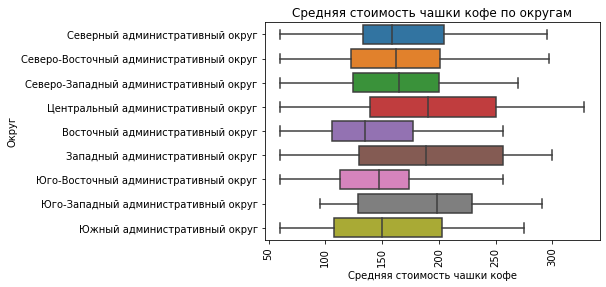

In [ ]:
# построим разброс стоимостей чашки капучино по АО 
fig_cafe_cup = sns.boxplot(data=data_cafe, x='middle_coffee_cup', y='district', showfliers=False)
fig_cafe_cup.set_title('Средняя стоимость чашки кофе по округам');
fig_cafe_cup.set_xlabel('Средняя стоимость чашки кофе');
fig_cafe_cup.set_ylabel('Округ');
plt.xticks(rotation=90);
plt.show();

In [ ]:
# создаём карту Москвы
cafe_map = Map(location=[moscow_lat, moscow_lng], zoom_start=10, tiles='Cartodb Positron')
# создаём хороплет с помощью конструктора Choropleth и добавляем его на карту
mm=Choropleth(
    geo_data=state_geo,
    data=data_cafe_cup,
    columns=['district', 'middle_coffee_cup'],
    key_on='feature.name',
    fill_color='OrRd',
    fill_opacity=0.5,
    legend_name='Медианная стоимость чашки каппучино по районам',
).add_to(cafe_map)
mm.geojson.add_child(folium.features.GeoJsonTooltip(['name',], labels=False))
# выводим карту
cafe_map

<br>1) Средняя стоимость чашки кофе в Москве варьируется от 150 до 190р. по округам Москвы.</br>
<br>2) Самые высокие стоимость кашки кофе в ЦАО, ЗАО и ЮЗАО.</br>
<br>3) Самая низкая стоимость ЮВАО.</br>

### Рекомендации:
При открытии кофейни стоит рассмотреть ЮЗАО, т.к. в этом районе высокая стоимость чашки кофе и небольшое количество кофеен. Преимуществом является то, что при открытии кофейни в этом округе, можно будет снизить цену без существенных потерь для привлечения клиентов и  невысокое количество конкурентов из 96 кофеен в ЮЗАО, так же маленькое количество кофеен работающий 24/7, в отличие от ЦАО в ЮЗАО посетителей в ночное время не так много, т.к округ в такое время не оживлен. В ЦАО, лучше ориентироваться на круглосуточный режим работы, т.к. это самый оживленный район в ночное время. Можно попробовать вариант с круглосуточным режимом работы и посмотреть будут ли в ночное время посетители, ведь если посетители будут, это будет большим преимуществом для бизнеса, т.к. конкурентов в ночное время мало. Также ЮЗАО подходит для открытия тем, что в нем низкий средний рейтинг у кофеин 4.2, что может стать преимуществом при успешном старте в данном районе. По моему мнению, если старт продаж покажет высокие результаты, то у круглосуточной кофейни в ЮЗАО, со стоимостью чашки кофе 165 рублей, то у бизнеса большая вероятность выйти в профит.

### Ссылка на презентацию
https://docs.yandex.ru/docs/view?url=ya-disk%3A%2F%2F%2Fdisk%2F%D0%9F%D1%80%D0%B5%D0%B7%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F%20(1).pdf&name=%D0%9F%D1%80%D0%B5%D0%B7%D0%B5%D0%BD%D1%82%D0%B0%D1%86%D0%B8%D1%8F%20(1).pdf&uid=547733905&nosw=1